This code does the following

*


In [48]:
## import libraries and modules
import numpy as np
import treecorr
import healpy as hp
import matplotlib.pyplot as plt
import read_functions
from astropy.cosmology import FlatLambdaCDM
from astropy import units as u

Plot measurements

Text(0.5, 0, '$r$ [Mpc]')

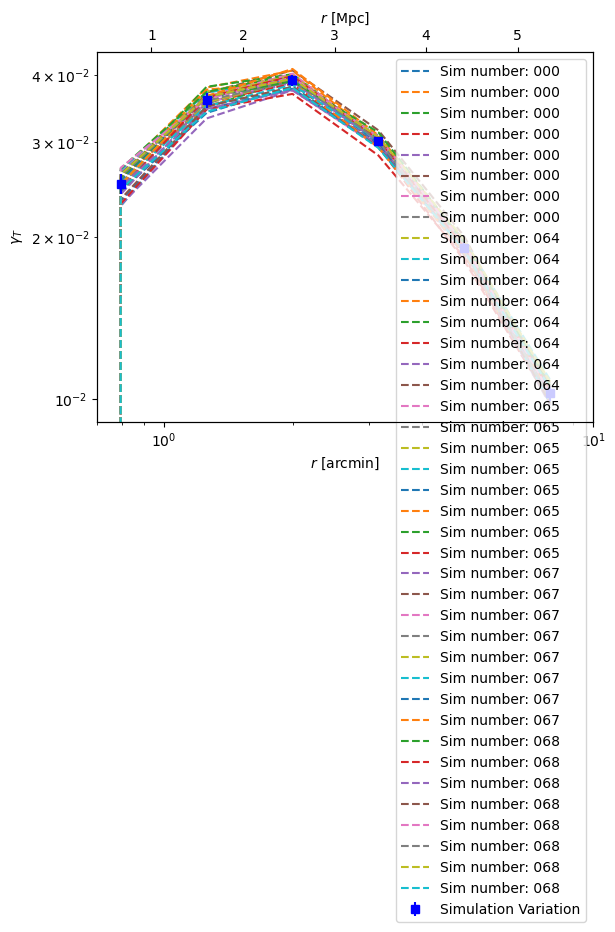

In [49]:
fig, ax1 = plt.subplots()
sim_names = ['000', '064', '065', '067', '068']
len_sim = len(sim_names)
nsky = 8
for ii in range(len_sim):
  for jj in range(nsky):
      sim_name = sim_names[ii]
      dat= np.genfromtxt('data/measurements/datavector_'+sim_name+'_patchN%i_%i.txt'%(nsky, jj))
      ax1.plot(dat[:, 0], dat[:, 3], '--', label = 'Sim number: '+sim_name)

      if ii == 0 and jj == 0:
         meas_rec = dat[:, 3]
      else:
         meas_rec = np.vstack((meas_rec, dat[:, 3]))
x_val = dat[:, 0]
y_val=np.mean(meas_rec, axis=0)
y_sim_err=np.std(meas_rec, axis=0)
ax1.errorbar(x_val, y_val, yerr=y_sim_err, fmt='bs', label='Simulation Variation')

ax1.legend(loc=0)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(0.7, 10)
ax1.set_xlabel(r'$r$ [arcmin]')
ax1.set_ylabel(r'$\gamma_T$')

## convert angular scale to physical scale
# Define the cosmology
cosmo = FlatLambdaCDM(H0=70.0, Om0=0.279) # Example values
# Define the redshift and angle
z_cl=0.53 ## need to change depending on the cluster sample
d_A = cosmo.comoving_distance(z_cl)

ax2 = ax1.twiny()
mn, mx = ax1.get_xlim()
ax2.set_xlim( (mn* u.arcmin).to(u.radian).value*d_A.value, (mx* u.arcmin).to(u.radian).value*d_A.value)
ax2.set_xlabel(r'$r$ [Mpc]')


Plotting the errorbar from covariance and simulation variation

Text(0.5, 0, '$r$ [Mpc]')

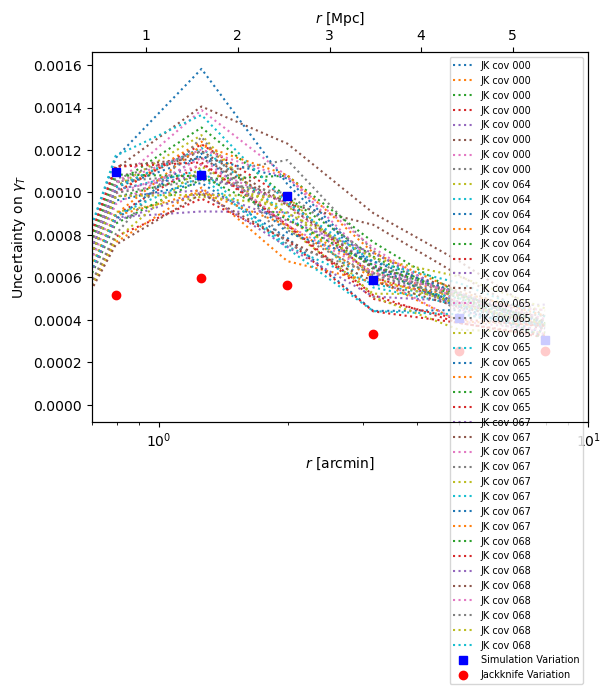

In [50]:
fig, ax1 = plt.subplots()
cov_jk = np.genfromtxt('data/measurements/cov_065_patchN2_0.txt')
y_jk_err=np.sqrt(np.diag(cov_jk))
ax1.errorbar(x_val, y_sim_err, fmt='bs', label='Simulation Variation')
ax1.errorbar(x_val, y_jk_err, fmt='ro', label='Jackknife Variation')

for ii in range(len_sim):
  for jj in range(nsky):
      sim_name = sim_names[ii]
      dat= np.genfromtxt('data/measurements/cov_'+sim_name+'_patchN%i_%i.txt'%(nsky, jj))
      y_jk_err=np.sqrt(np.diag(dat))
      ax1.plot(x_val, y_jk_err, ':', label='JK cov '+sim_name)

ax1.legend(loc=0, fontsize=7)
ax1.set_xscale('log')
ax1.set_xlim(0.7, 10)
ax1.set_xlabel(r'$r$ [arcmin]')
ax1.set_ylabel(r'Uncertainty on $\gamma_T$')

## convert angular scale to physical scale
ax2 = ax1.twiny()
mn, mx = ax1.get_xlim()
ax2.set_xlim( (mn* u.arcmin).to(u.radian).value*d_A.value, (mx* u.arcmin).to(u.radian).value*d_A.value)
ax2.set_xlabel(r'$r$ [Mpc]')